In [1]:
import pandas as pd
import numpy as np
from pybads import BADS
import matplotlib.pyplot as plt
import seaborn as sns
from potencial import get_expressions
from sim_helpers_fit import simulate_path, make_drift
from sim_helpers_fit_numba import run_trial_numba

In [2]:
df = pd.read_csv('./datasets/df_filtered.csv', sep = ';')
# Count rows per subject
subject_counts = df['subject'].value_counts()
print("Number of rows per subject:")
print(subject_counts)
# Calculate percentage of rows with timepoint_4 > 5 for each subject
timepoint_high_pct = {}
for subject in df['subject'].unique():
    subject_df = df[df['subject'] == subject]
    high_timepoint = subject_df[subject_df['timepoint_4'] > 7.5].shape[0]
    total = subject_df.shape[0]
    timepoint_high_pct[subject] = (high_timepoint / total) * 100

# Convert to Series for better display
timepoint_high_series = pd.Series(timepoint_high_pct)
print("\nPercentage of rows with timepoint_4 > 7.5s by subject:")
print(timepoint_high_series)
# Summary statistics
print("\nSummary statistics:")
print(f"Total subjects: {len(subject_counts)}")
print(f"Average rows per subject: {subject_counts.mean():.2f}")
print(f"Minimum rows per subject: {subject_counts.min()}")
print(f"Maximum rows per subject: {subject_counts.max()}")

# df = df[df['timepoint_4']<=5]


Number of rows per subject:
subject
A92    34552
A89    25450
A87    22947
A86    22804
A83    18211
A93    10942
A84      792
Name: count, dtype: int64

Percentage of rows with timepoint_4 > 7.5s by subject:
A83    3.624183
A84    8.964646
A86    3.025785
A87    2.610363
A89    4.153242
A92    4.352859
A93    5.136173
dtype: float64

Summary statistics:
Total subjects: 7
Average rows per subject: 19385.43
Minimum rows per subject: 792
Maximum rows per subject: 34552


In [3]:
print(df['timepoint_1'].describe())
print(len(df[df['timepoint_1']<0]))
df = df[df['timepoint_1'] > 0]  # Ensure timepoint_1 is positive
print(df['timepoint_2'].describe())
print(df['timepoint_3'].describe())
print(df['timepoint_4'].describe())


count    135698.000000
mean          0.651473
std           1.786218
min           0.006200
25%           0.459700
50%           0.573100
75%           0.725500
max         569.407800
Name: timepoint_1, dtype: float64
0
count    135698.000000
mean          1.094617
std           2.133141
min           0.144400
25%           0.807700
50%           0.969300
75%           1.182100
max         569.856100
Name: timepoint_2, dtype: float64
count    135698.000000
mean          1.486139
std           2.252729
min           0.328700
25%           1.135100
50%           1.336400
75%           1.601800
max         570.661300
Name: timepoint_3, dtype: float64
count    135698.000000
mean          3.712384
std           3.412551
min           0.844500
25%           2.554200
50%           3.082500
75%           3.948600
max         574.024200
Name: timepoint_4, dtype: float64


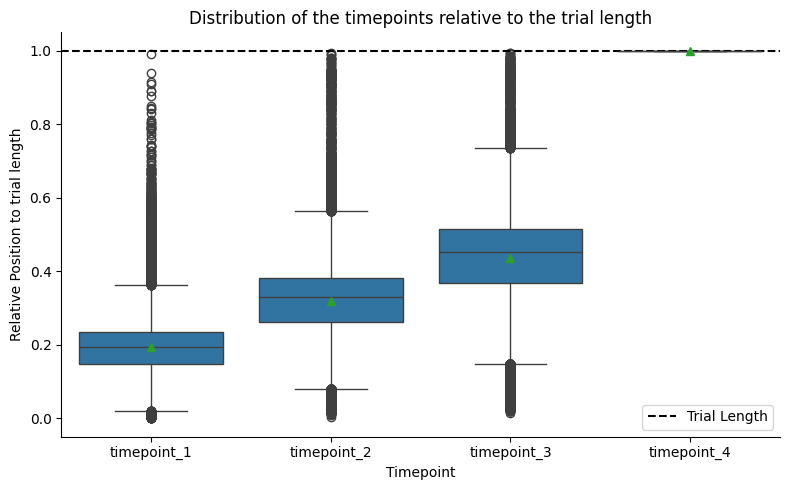

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Suponiendo que df es tu DataFrame completo con muchas columnas

# Seleccionamos solo las columnas de timepoints
timepoint_cols = [col for col in df.columns if col.startswith('timepoint_')]

# Nos aseguramos de que 'timepoint_4' esté incluido y sea el denominador
if 'timepoint_4' not in timepoint_cols:
    raise ValueError("No se encuentra 'timepoint_4' en las columnas.")

# Normalizamos solo esas columnas respecto a timepoint_4
df_rel = df[timepoint_cols].div(df['timepoint_4'], axis=0)

# Convertimos a formato largo
df_long = df_rel.melt(var_name='timepoint', value_name='relative_position')

# Ordenamos por número de timepoint
order = sorted(df_long['timepoint'].unique(), key=lambda x: int(x.split('_')[1]))

# Gráfico
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_long, x='timepoint', y='relative_position', order=order,
            showmeans=True,)

plt.axhline(1.0, ls='--', color='black', label='Trial Length')
plt.ylabel('Relative Position to trial length')
plt.xlabel('Timepoint')
plt.title('Distribution of the timepoints relative to the trial length')
plt.legend()
plt.tight_layout()
sns.despine()
plt.show()


In [9]:
import os
import pickle
import pandas as pd
from fitting_numba_full import objective_function

params_folder = 'params_result'


param_names = [
    'sL', 'sC', 'sR', 'noise_amp', 'S_amplitude', 'S_d',
    'U_int_amplitude', 'U_int_baseline', 'U_int_onset', 'U_ext_amplitude'
]

rows = []

for filename in os.listdir(params_folder):
    if filename.startswith('result_') and filename.endswith('.pkl') and 'A92_' not in filename:
        subject = filename.replace('result_', '').replace('.pkl', '')

        with open(os.path.join(params_folder, filename), 'rb') as f:
            result_obj = pickle.load(f)
        print(f'{result_obj.fval*100:.2f}')
        # Extraer el array de parámetros desde .x
        if hasattr(result_obj, 'x'):
            global_params = result_obj.x
        elif isinstance(result_obj, dict) and '.x' in result_obj:
            global_params = result_obj['.x']
        else:
            raise ValueError(f"No se encontró `.x` en {filename}")
        print(f"Parámetros globales para {subject}: {global_params}")
        row = {'subject': subject}
        for name, val in zip(param_names, global_params):
            row[name] = val
        rows.append(row)

# Add A89_nll entry manually
a89_nll_params = [-0.00741586, 0.01047864, 0.04081191, 1.60911907, 0.20905649, 0.99279804, 
                    1.79848623, -0.2999274, 1.77094916, 0.0]  # Adding 0 for U_ext_amplitude
a89_crn_params = [ 5.93288788e-01 , 6.00104117e-01 , 6.47263681e-01 , 6.61103241e-01 ,
  1.17213194e-01 , 8.06228220e-01 , 8.88418999e-01 ,-9.77977067e-01 ,
  6.39746286e-04]
a88_crn_params = [ 6.65900680e-01 , 6.67237234e-01 , 6.80509841e-01 , 1.40146127e+00, 2.49846595e-01 , 9.99819568e-01 , 1.16811680e+00 , -1.30533029e+00,  1.73671303e-07]
rows.append({'subject': 'A88_crn'})
for name, val in zip(param_names, a88_crn_params):
    rows[-1][name] = val

params_df = pd.DataFrame(rows)
params_df = params_df.sort_values(by='subject').reset_index(drop=True)
params_df.to_csv(f'{params_folder}/params_df.csv', index=False)


29.04
Parámetros globales para A89: [ 0.19097037 -0.05198497  0.23722525  0.31695559  0.46290597  1.
  1.58596479 -1.77578807  0.45844973]
22.60
Parámetros globales para A88: [-0.06816393 -0.02364892 -0.09528732  0.01000005  0.58828981  0.70929098
  1.9121747  -1.67679721  0.74271046]
29.39
Parámetros globales para A89_th2_1: [-0.1718362  -0.04373192 -0.02088562  0.70508509  0.53826295  0.99994309
  1.12249406 -1.17098627  0.53768925]
29.69
Parámetros globales para A92: [ 0.03871515  0.20816751  0.05618211  0.01002432  0.62808119  0.99997556
  1.77316378 -1.82098126  0.93509719]
26.99
Parámetros globales para A86: [-0.00756605  0.15408363 -0.05272293  0.01111193  0.49121145  0.49661241
  1.65778339 -1.76164867  0.42999097]
32.60
Parámetros globales para A87: [-0.02988008 -0.21110687 -0.30629488  0.07891179  0.35811163  0.99999349
  1.78455825 -1.52132052  0.85838677]


In [10]:
def strip_darken(ax):
    for collection in ax.collections:
        try:
            facecolors = collection.get_facecolors()
        except AttributeError:
            continue
        if len(facecolors) > 0:
            new_edgecolors = []
            for fc in facecolors:
                darkened = fc.copy()
                # Multiplicamos los valores RGB por 0.7 para oscurecer; ajustar si es necesario.
                darkened[:3] = darkened[:3] * 0.7
                new_edgecolors.append(darkened)
            collection.set_edgecolors(new_edgecolors)
            collection.set_linewidth(1.5)
    return

/var/folders/gk/r166p6nx2bb5zf2rlwww8fc00000gn/T/ipykernel_63086/1191416649.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melted, x='parameter', y='value', palette='Set2', ax=ax)
/var/folders/gk/r166p6nx2bb5zf2rlwww8fc00000gn/T/ipykernel_63086/1191416649.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_melted, x='parameter', y='value', color='black', palette='Set2',alpha=0.5, jitter=True, ax=ax)


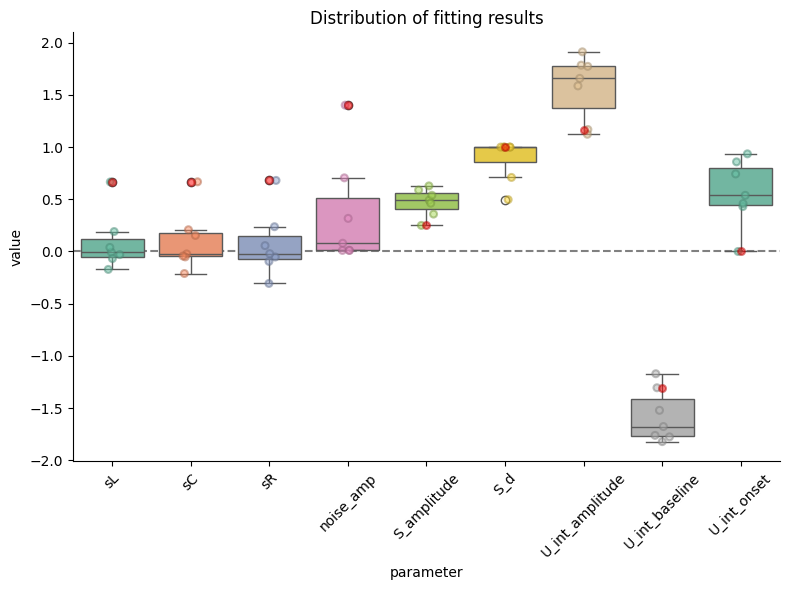

In [13]:
df_melted = params_df.melt(id_vars='subject', var_name='parameter', value_name='value')

# Boxplot
plt.figure(figsize=(8, 6))
ax = plt.gca()
ax.hlines(0, xmin=-0.5, xmax=len(df_melted['parameter'].unique())-0.5, color='gray', linestyle='--')
sns.boxplot(data=df_melted, x='parameter', y='value', palette='Set2', ax=ax)
sns.stripplot(data=df_melted, x='parameter', y='value', color='black', palette='Set2',alpha=0.5, jitter=True, ax=ax)
sns.stripplot(data=df_melted[df_melted['subject'] == 'A88_crn'], x='parameter', y='value', color='red', alpha=0.5, jitter=True, ax=ax)
strip_darken(ax)
plt.title('Distribution of fitting results')
plt.xticks(rotation=45)

plt.grid(False)
plt.tight_layout()
sns.despine()
plt.show()

In [12]:
import os
import pickle
import pandas as pd
from fitting_numba_full import objective_function

params_folder = 'params_result'


param_names = [
    'sL', 'sC', 'sR', 'noise_amp', 'S_amplitude', 'S_d',
    'U_int_amplitude', 'U_int_baseline', 'U_int_onset'
]

rows = []

for filename in os.listdir(params_folder):
    if filename.startswith('result_A92_') and filename.endswith('.pkl'):
        subject = filename.replace('result_A86_', '').replace('.pkl', '')

        with open(os.path.join(params_folder, filename), 'rb') as f:
            result_obj = pickle.load(f)
        print(f'{result_obj.fval*100:.2f}')
        # Extraer el array de parámetros desde .x
        if hasattr(result_obj, 'x'):
            global_params = result_obj.x
        elif isinstance(result_obj, dict) and '.x' in result_obj:
            global_params = result_obj['.x']
        else:
            raise ValueError(f"No se encontró `.x0` en {filename}")

        row = {'subject': subject}
        for name, val in zip(param_names, global_params):
            row[name] = val
        rows.append(row)

x0_df = pd.DataFrame(rows)
x0_df = x0_df.sort_values(by='subject').reset_index(drop=True)



29.62
29.81
29.68
30.21
30.11
29.89
29.83
29.80
29.69
30.33


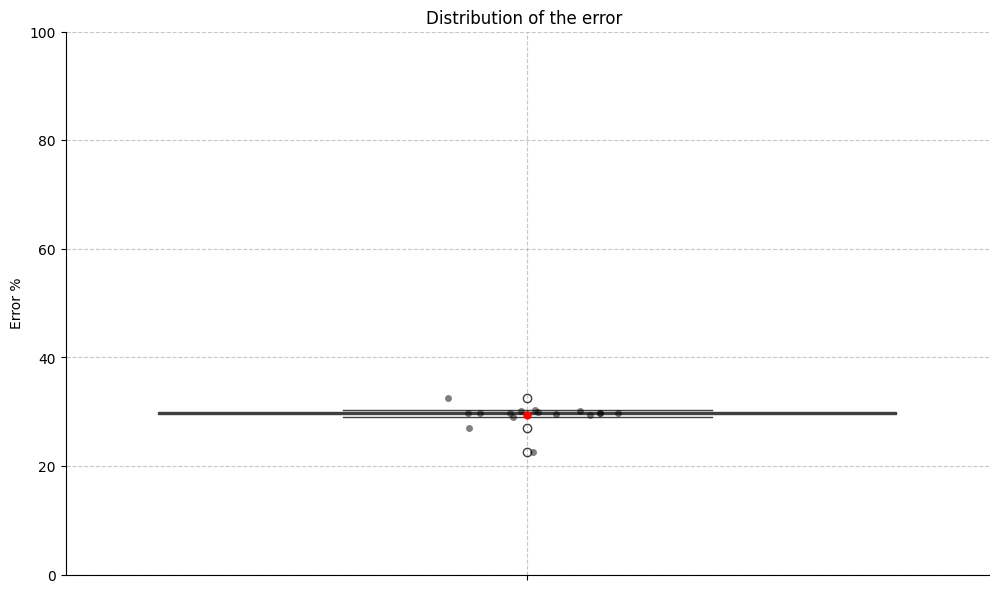


Parameter values:


,subject,fval
0,A92_4,29.617215
1,A92_5,29.811904
2,A92_7,29.679075
3,A92_6,30.208116
4,A92_2,30.113289
5,A92_3,29.891866
6,A92_1,29.833004
7,A89,29.036425
8,A88,22.601848
9,A92_10,29.803513


In [112]:
import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

params_folder = 'params_result'

param_names = [
    'sL', 'sC', 'sR', 'noise_amp', 'S_amplitude', 'S_d',
    'U_int_amplitude', 'U_int_baseline', 'U_int_onset', 'U_ext_amplitude'
]

rows = []
fvals = []

for filename in os.listdir(params_folder):
    if filename.startswith('result_') and filename.endswith('.pkl'):
        subject = filename.replace('result_', '').replace('.pkl', '')

        with open(os.path.join(params_folder, filename), 'rb') as f:
            result_obj = pickle.load(f)
        
        # Extract fval for plotting
        fval = result_obj.fval * 100
        fvals.append({'subject': subject, 'fval': fval})
        
        # Extract the array of parameters from .x
        if hasattr(result_obj, 'x'):
            global_params = result_obj.x
        elif isinstance(result_obj, dict) and '.x' in result_obj:
            global_params = result_obj['.x']
        else:
            raise ValueError(f"No se encontró `.x` en {filename}")

        # Make sure we have the right number of parameters
        if len(global_params) == len(param_names):
            row = {'subject': subject}
            for name, val in zip(param_names, global_params):
                row[name] = val
            rows.append(row)
        else:
            print(f"Warning: Parameter count mismatch in {filename}. Expected {len(param_names)}, got {len(global_params)}")

# Create DataFrame of parameters
x0_df = pd.DataFrame(rows)
# x0_df = x0_df.sort_values(by='subject').reset_index(drop=True)

# Create DataFrame of fvals for boxplot
fvals_df = pd.DataFrame(fvals)

# Plot boxplot of fvals
plt.figure(figsize=(10, 6))
sns.boxplot(y='fval', data=fvals_df)
sns.stripplot(y='fval', data=fvals_df, color='black', alpha=0.5)
sns.stripplot(y='fval', data=fvals_df[fvals_df['subject']== 'A89_th2_1'], color='red', alpha=1, jitter=True, size=6)
plt.title('Distribution of the error ')
plt.ylabel('Error %')
plt.grid(True, linestyle='--', alpha=0.7)
sns.despine()
plt.tight_layout()
plt.ylim(bottom=0, top = 100)
plt.show()

# Display the parameter dataframe
print("\nParameter values:")
display(fvals_df)


/var/folders/gk/r166p6nx2bb5zf2rlwww8fc00000gn/T/ipykernel_35398/2640330205.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melted, x='parameter', y='value', palette='Set2', ax=ax)
/var/folders/gk/r166p6nx2bb5zf2rlwww8fc00000gn/T/ipykernel_35398/2640330205.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_melted, x='parameter', y='value', color='black', palette='Set2',alpha=0.5, jitter=True, ax=ax)


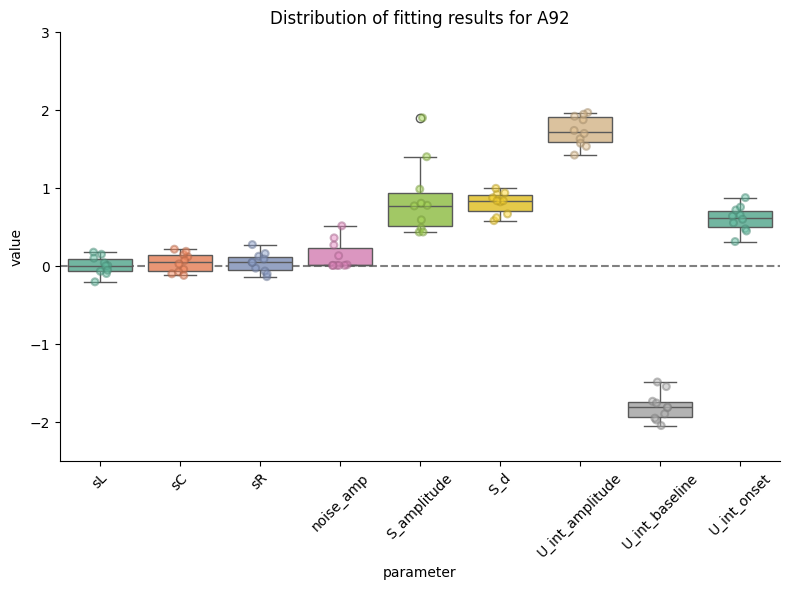

In [ ]:
df_melted = x0_df.melt(id_vars='subject', var_name='parameter', value_name='value')

# Boxplot
plt.figure(figsize=(8, 6))
ax = plt.gca()
ax.hlines(0, xmin=-0.5, xmax=len(df_melted['parameter'].unique())-0.5, color='gray', linestyle='--')
sns.boxplot(data=df_melted, x='parameter', y='value', palette='Set2', ax=ax)
sns.stripplot(data=df_melted, x='parameter', y='value', color='black', palette='Set2',alpha=0.5, jitter=True, ax=ax)
strip_darken(ax)
plt.title('Distribution of fitting results for A92')
plt.xticks(rotation=45)
plt.ylim(-2.5, 3)
plt.grid(False)
sns.despine()
plt.tight_layout()
plt.show()

/var/folders/gk/r166p6nx2bb5zf2rlwww8fc00000gn/T/ipykernel_35398/825991829.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_melted, x='parameter', y='value', palette='Set2')
/var/folders/gk/r166p6nx2bb5zf2rlwww8fc00000gn/T/ipykernel_35398/825991829.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_melted, x='parameter', y='value', color='black', palette='Set2',alpha=0.5, jitter=True, ax = ax)


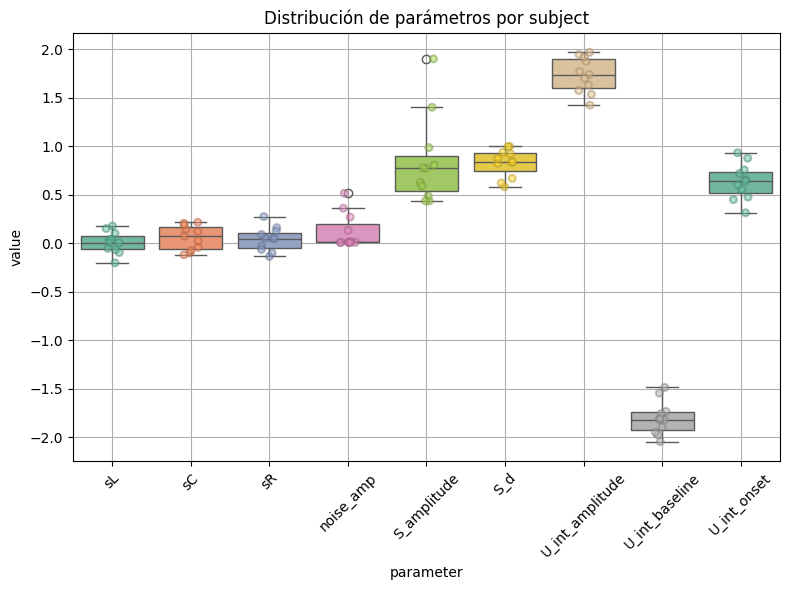

In [45]:
params_df_A86N = params_df[params_df['subject'].str.contains('A92')].copy()
df_melted = params_df_A86N.melt(id_vars='subject', var_name='parameter', value_name='value')

# Boxplot
plt.figure(figsize=(8, 6))
ax = sns.boxplot(data=df_melted, x='parameter', y='value', palette='Set2')
sns.stripplot(data=df_melted, x='parameter', y='value', color='black', palette='Set2',alpha=0.5, jitter=True, ax = ax)
strip_darken(ax)
plt.title('Distribución de parámetros por subject')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

/var/folders/gk/r166p6nx2bb5zf2rlwww8fc00000gn/T/ipykernel_2417/3514770173.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


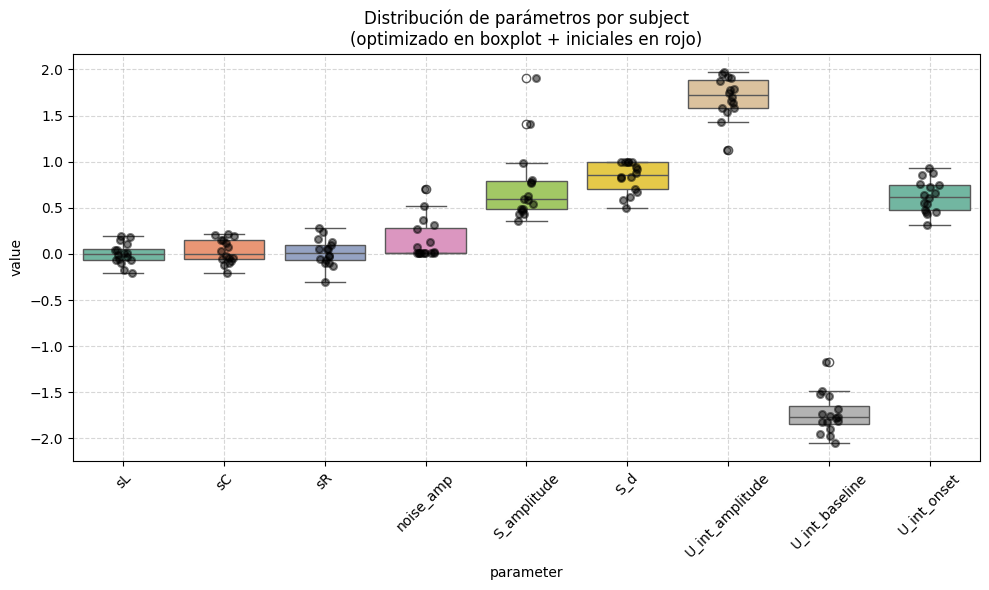

In [25]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from fitting_numba_full import objective_function

params_folder = 'params_result'

param_names = [
    'sL', 'sC', 'sR', 'noise_amp', 'S_amplitude', 'S_d',
    'U_int_amplitude', 'U_int_baseline', 'U_int_onset', 'U_ext_amplitude'
]

# ————————————————————————
# 1) Carga de resultados optimizados (result_*.pkl)
# ————————————————————————
opt_rows = []
opt_dict = {}   # para acceder luego a .x por sujeto
for filename in os.listdir(params_folder):
    if filename.startswith('result_') and filename.endswith('.pkl'):
        subject = filename.replace('result_', '').replace('.pkl', '')
        with open(os.path.join(params_folder, filename), 'rb') as f:
            res = pickle.load(f)
        # Sacamos .x
        if hasattr(res, 'x'):
            x_opt = np.array(res.x)
        elif isinstance(res, dict) and '.x' in res:
            x_opt = np.array(res['.x'])
        else:
            raise ValueError(f"No se encontró `.x` en {filename}")
        opt_dict[subject] = x_opt
        row = {'subject': subject}
        for name, val in zip(param_names, x_opt):
            row[name] = val
        opt_rows.append(row)

params_df = pd.DataFrame(opt_rows)
params_df = params_df.sort_values('subject').reset_index(drop=True)
df_melted = params_df.melt(id_vars='subject', var_name='parameter', value_name='value')

# ————————————————————————
# 2) Carga de los x0 (result2_*.pkl) y cálculo de diferencias
# ————————————————————————
init_dict = {}
for filename in os.listdir(params_folder):
    if filename.startswith('result2_') and filename.endswith('.pkl'):
        subject = filename.replace('result2_', '').replace('.pkl', '')
        with open(os.path.join(params_folder, filename), 'rb') as f:
            res2 = pickle.load(f)
        if hasattr(res2, 'x0'):
            x0 = np.array(res2.x0)
        elif isinstance(res2, dict) and 'x0' in res2:
            x0 = np.array(res2['x0'])
        else:
            raise ValueError(f"No se encontró `.x0` en {filename}")

        # Comprobar que existe un resultado optimizado
        if subject not in opt_dict:
            print(f"[Aviso] No hay resultado optimizado para sujeto {subject}; se omite.")
            continue

        x_opt = opt_dict[subject]
        diff = x_opt - x0

        init_dict[subject] = x0

        # Imprimir x0 y diferencias
        print(f"Subject: {subject}")
        print(f"  x0 : {x0}")
        print(f"  diff: {diff}\n")

# ————————————————————————
# 3) Ploteo: boxplot + puntos rojos de x0
# ————————————————————————
plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=df_melted, 
    x='parameter', 
    y='value', 
    palette='Set2'
)
sns.stripplot(
    data=df_melted, 
    x='parameter', 
    y='value', 
    color='black', 
    alpha=0.5, 
    jitter=True, 
    ax=ax
)

# Añadimos los puntos rojos para cada sujeto en result2_
# Asumimos que todos los vectores x0 tienen la misma longitud y orden que param_names
x_positions = np.arange(len(param_names))
for subj, x0 in init_dict.items():
    ax.scatter(
        x_positions, 
        x0, 
        color='red', 
        marker='o', 
        s=50, 
        alpha=0.8,
        label='_nolegend_'  # para que no duplique leyenda
    )

strip_darken(ax)
plt.title('Distribución de parámetros por subject\n(optimizado en boxplot + iniciales en rojo)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [26]:
# ————————————————————————————————————————————————
# 4) Cálculo de diferencias de fval y coeficientes solo para sujetos con ambos archivos
# ————————————————————————————————————————————————

fval_diffs = []
coefs_diffs = []

for filename in os.listdir(params_folder):
    if filename.startswith('result2_') and filename.endswith('.pkl'):
        subject = filename.replace('result2_', '').replace('.pkl', '')
        path_opt = os.path.join(params_folder, f'result_{subject}.pkl')
        path_init = os.path.join(params_folder, f'result2_{subject}.pkl')

        if not os.path.exists(path_opt):
            print(f"[Aviso] Falta result_ para {subject}; se omite.")
            continue
        if not os.path.exists(path_init):
            print(f"[Aviso] Falta result2_ para {subject}; se omite.")
            continue

        # Carga fval optimizado
        with open(path_opt, 'rb') as f:
            res = pickle.load(f)
            fval_opt = float(res.fval)*100
        # Carga fval inicial
        with open(path_init, 'rb') as f:
            res2 = pickle.load(f)
            fval_init = float(res2.fval)*100

        fval_diffs.append({
            'subject': subject,
            'fval_optimized': fval_opt,
            'fval_init': fval_init,
            'delta_fval': fval_opt - fval_init
        })

        # Carga x0 y x_opt (ya tienes opt_dict y init_dict, pero lo hacemos robusto)
        if hasattr(res2, 'x0'):
            x0 = np.array(res2.x0)
        elif isinstance(res2, dict) and 'x0' in res2:
            x0 = np.array(res2['x0'])
        else:
            print(f"[Aviso] No se encontró x0 en {subject}.")
            continue

        if hasattr(res, 'x'):
            x_opt = np.array(res.x)
        elif isinstance(res, dict) and '.x' in res:
            x_opt = np.array(res['.x'])
        else:
            print(f"[Aviso] No se encontró x en {subject}.")
            continue

        # Si x0 es 2D (1 fila), aplánalo
        if isinstance(x0, np.ndarray) and x0.ndim == 2 and x0.shape[0] == 1:
            x0 = x0[0]
        if isinstance(x_opt, np.ndarray) and x_opt.ndim == 2 and x_opt.shape[0] == 1:
            x_opt = x_opt[0]

        if (len(x0) != len(param_names)) or (len(x_opt) != len(param_names)):
            print(f"[IGNORADO] {subject}: x0 ({len(x0)}), x_opt ({len(x_opt)}), param_names ({len(param_names)})")
            continue

        for i, pname in enumerate(param_names):
            coefs_diffs.append({
                'subject': subject,
                'parameter': pname,
                'diff': x_opt[i] - x0[i],
                'x_opt': x_opt[i],
                'x0': x0[i]
            })

# DataFrames para los plots
df_fval_diff = pd.DataFrame(fval_diffs)
df_coefs_diff = pd.DataFrame(coefs_diffs)

# ————————————————————————————————————————————————
# 5) Plot diferencias de fval (barplot)
# ————————————————————————————————————————————————

plt.figure(figsize=(8, 5))
plt.bar(df_fval_diff['subject'], df_fval_diff['delta_fval'], color='C1', alpha=0.8)
plt.axhline(0, color='k', linestyle='--', lw=1)
plt.xlabel('Subject')
plt.ylabel(r'$\Delta$ fval (opt - init)')
plt.title('Diferencia de función objetivo (optimizado - inicial)')
plt.tight_layout()
plt.show()

# ————————————————————————————————————————————————
# 6) Plot diferencias de parámetros (boxplot + stripplot)
# ————————————————————————————————————————————————

plt.figure(figsize=(10, 6))
ax2 = sns.boxplot(
    data=df_coefs_diff,
    x='parameter',
    y='diff',
    palette='Set2'
)
sns.stripplot(
    data=df_coefs_diff,
    x='parameter',
    y='diff',
    color='black',
    alpha=0.7,
    jitter=True,
    ax=ax2
)
plt.axhline(0, color='k', linestyle='--', lw=1)
plt.title('Diferencia en parámetros')
plt.ylabel('Optimizado - Inicial')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


KeyError: 'subject'

<Figure size 800x500 with 0 Axes>

In [27]:
def get_onset_offset(stim_dur, delay_dur, timepoint_1, timepoint_2, timepoint_3, timepoint_4):
    """
    Devuelve los posibles valores de onset y el valor de offset
    según el tipo de trial.
    """
    if stim_dur == 'VG':
        onset = 0
        offset = timepoint_4

    elif stim_dur == 'SS':
        if delay_dur == 'DS':
            onset = timepoint_2
            offset = timepoint_3
        elif delay_dur == 'DM':
            onset = timepoint_1
            offset = timepoint_2
        elif delay_dur == 'DL':
            onset = 0
            offset = timepoint_1

    elif stim_dur == 'SM':
        if delay_dur == 'DS':
            onset = timepoint_1
            offset = timepoint_3
        elif delay_dur == 'DM':
            onset = 0
            offset = timepoint_2

    elif stim_dur == 'SL':
        onset = 0
        offset = timepoint_3
    
    elif stim_dur == 'SIL':
        onset = 0
        offset = 0

    else:
        raise ValueError(f"stim_dur desconocido: {stim_dur}")

    return onset, offset


In [17]:
# Reimportamos tras el reset
import pandas as pd

# Simulación del DataFrame con los parámetros de un subject
subject_id = 'A88_crn'
params_df = pd.read_csv(f'{params_folder}/params_df.csv')


In [18]:
from collections import defaultdict


df[['onset', 'offset']] = df.apply(
    lambda row: pd.Series(get_onset_offset(
        row['stimd_c'], row['ttype_c'],
        row['timepoint_1'], row['timepoint_2'],
        row['timepoint_3'], row['timepoint_4']
    )),
    axis=1
)



NameError: name 'get_onset_offset' is not defined

In [19]:

df['t4_bin'] = pd.qcut(df['timepoint_4'], 3, labels=['low', 'mid', 'high'])
df['onset_bin'] = pd.cut(df['onset'], bins=8)


subject_params = params_df[params_df['subject'] == 'A89_nll'].iloc[0]
s_params = {'sL': subject_params.sL, 'sC': subject_params.sC, 'sR': subject_params.sR}
global_params = subject_params  # alias
N_SIM = 2000


predictions_by_bin = defaultdict(list)
accuracy_real = defaultdict(list)
bin_centers = defaultdict(list)

for t4_label in ['low', 'mid', 'high']:
    df_t4 = df[df['t4_bin'] == t4_label]
    for onset_bin, group in df_t4.groupby('onset_bin'):
        if len(group) < 5 or pd.isna(onset_bin): continue
        subset = group.sample(min(len(group), 20))  # trials representativos

        corrects = 0
        stim_onsets = []
        for _, row in subset.iterrows():
            side = row['x_c'] if row['ttype_c'] != 'SIL' else 'SIL'
            onset, offset = row['onset'], row['offset']
            Tmax = row['timepoint_4']

            S_params = {
                'offset': offset,
                'onset': onset,
                'd': global_params['S_d'],
                'amplitude': global_params['S_amplitude'],
            }
            U_int_params = {
                'offset': Tmax,
                'amplitude': global_params['U_int_amplitude'],
                'baseline': global_params['U_int_baseline'],
                'onset': global_params['U_int_onset'],
            }
            U_ext_params = {
                'offset': Tmax,
                'onset': onset,
                'amplitude': global_params['U_ext_amplitude'],
            }

            for _ in range(N_SIM // len(subset)):
                sim = run_trial_numba(
                    side=side,
                    S_params=S_params,
                    U_int_params=U_int_params,
                    U_ext_params=U_ext_params,
                    s_params=s_params,
                    Tmax=Tmax,
                    dt=0.1 / 40,
                    noise_amp=global_params['noise_amp']
                )
                if sim == row['r_c']:
                    corrects += 1
            stim_onsets.append(onset)

        predictions_by_bin[t4_label].append(corrects / N_SIM)
        accuracy_real[t4_label].append(group['correct_bool'].mean())
        bin_centers[t4_label].append(np.mean(stim_onsets))

KeyError: 'onset'

/var/folders/gk/r166p6nx2bb5zf2rlwww8fc00000gn/T/ipykernel_63086/3181162221.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df_sil.groupby('t4_bin_fino')['correct_bool'].agg(['mean', 'count', 'std']).reset_index()


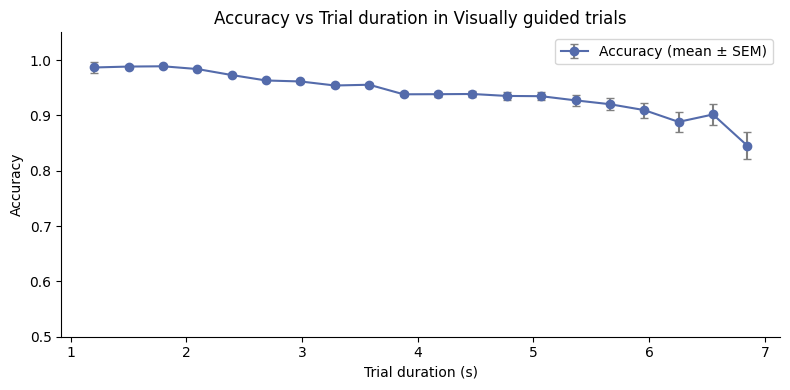

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Filtramos solo SIL
df_sil = df[df['ttype_c'] == 'VG'].copy()

# Número de bins finos (ajusta a tu gusto)
n_bins_fino = 20

# Binning de t4
df_sil = df_sil[df_sil['timepoint_4']<=7]
df_sil['t4_bin_fino'] = pd.cut(df_sil['timepoint_4'], bins=n_bins_fino)
# Calculamos la media y el error estándar de la media (SEM) en cada bin
summary = df_sil.groupby('t4_bin_fino')['correct_bool'].agg(['mean', 'count', 'std']).reset_index()
summary['sem'] = summary['std'] / np.sqrt(summary['count'])

# Centro de cada bin para el eje X
summary['t4_bin_center'] = summary['t4_bin_fino'].apply(lambda x: x.mid)

plt.figure(figsize=(8,4))
plt.errorbar(summary['t4_bin_center'], summary['mean'], yerr=summary['sem'], 
             fmt='o-', color='#546bab', ecolor='gray', capsize=3, label='Accuracy (mean ± SEM)')
plt.xlabel('Trial duration (s)')
plt.ylabel('Accuracy')
plt.title(f'Accuracy vs Trial duration in Visually guided trials')
# plt.ylim(-0.05, 1.05)
plt.grid(False)
plt.ylim(0.5, 1.05)
plt.tight_layout()
plt.legend()
sns.despine()
plt.show()



KeyError: 'onset'

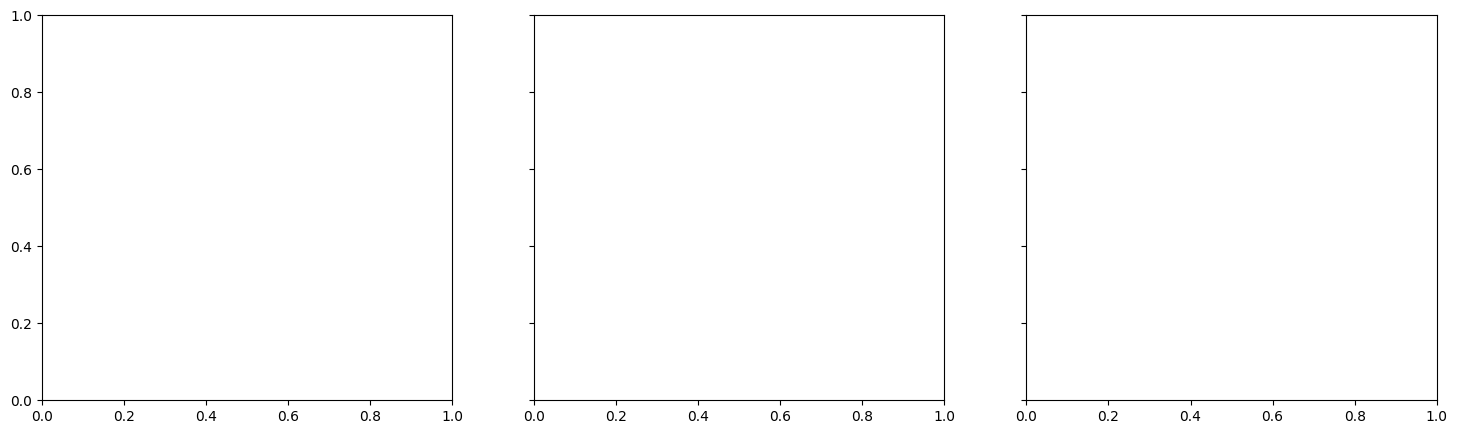

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df_nonsil = df[df['ttype_c'] != 'SIL'].copy()
n_bins_onset = 5   # bins no nulos (además del de onset=0)
n_bins_offset = 4

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
t4_labels = ['low', 'mid', 'high']
colors = plt.cm.plasma(np.linspace(0.2, 0.9, n_bins_offset))

for i, t4_bin in enumerate(t4_labels):
    ax = axes[i]
    df_t4 = df_nonsil[df_nonsil['t4_bin'] == t4_bin].copy()

    # Separamos los trials con onset=0
    df_onset0 = df_t4[df_t4['onset'] == 0].copy()
    df_rest   = df_t4[df_t4['onset'] > 0].copy()

    # Hacemos binning de onset solo sobre los que no son 0
    if len(df_rest) > 0:
        t_all = np.concatenate([
            df_rest['timepoint_1'].values,
            df_rest['timepoint_2'].values,
            df_rest['timepoint_3'].values,
            df_rest['timepoint_4'].values,
        ])
        n_bins_onset_eff = min(n_bins_onset, len(np.unique(t_all)))
        onset_bins = pd.qcut(t_all, n_bins_onset_eff, retbins=True, duplicates='drop')[1]
        # Asegurarse que el borde izquierdo es >0 (para no "pisar" el 0)
        onset_bins[0] = np.nextafter(0, 1)
        df_rest['onset_bin'] = pd.cut(df_rest['onset'], bins=onset_bins, include_lowest=True)
    else:
        df_rest['onset_bin'] = pd.Series(dtype='category')

    # Para onset=0 ponemos una categoría especial
    df_onset0['onset_bin'] = 'onset=0'

    # Juntamos de nuevo
    df_t4 = pd.concat([df_onset0, df_rest], axis=0)
    # Hacemos binning de offset normalmente
    t_all_offset = np.concatenate([
        df_t4['timepoint_1'].values,
        df_t4['timepoint_2'].values,
        df_t4['timepoint_3'].values,
        df_t4['timepoint_4'].values,
    ])
    n_bins_offset_eff = min(n_bins_offset, len(np.unique(t_all_offset)))
    offset_bins = pd.qcut(t_all_offset, n_bins_offset_eff, retbins=True, duplicates='drop')[1]
    df_t4['offset_bin'] = pd.cut(df_t4['offset'], bins=offset_bins, include_lowest=True)

    # Definir el orden de onset_bin: primero onset=0, luego los numéricos en orden
    onset_bins_ordered = ['onset=0'] + [str(c) for c in df_rest['onset_bin'].cat.categories]
    offset_bins_ordered = df_t4['offset_bin'].cat.categories

    # Centros de los onset bins: onset=0 es simplemente 0, el resto como antes
    onset_bin_centers = [0.0]  # para onset=0
    for onset_bin in df_rest['onset_bin'].cat.categories:
        subset = df_rest[df_rest['onset_bin'] == onset_bin]
        if not subset.empty:
            all_times = np.concatenate([
                subset['timepoint_1'].values,
                subset['timepoint_2'].values,
                subset['timepoint_3'].values,
                subset['timepoint_4'].values,
            ])
            onset_bin_centers.append(np.median(all_times))
        else:
            onset_bin_centers.append(np.nan)

    for j, offset_bin in enumerate(offset_bins_ordered):
        acc_real = []
        sem_real = []
        for k, onset_bin in enumerate(onset_bins_ordered):
            if onset_bin == 'onset=0':
                df_bin = df_t4[df_t4['onset_bin'] == onset_bin]
            else:
                df_bin = df_t4[df_t4['onset_bin'] == onset_bin]
            df_bin = df_bin[df_bin['offset'] > df_bin['onset']]
            if len(df_bin) == 0:
                acc_real.append(np.nan)
                sem_real.append(np.nan)
            else:
                acc_real.append(df_bin['correct_bool'].mean())
                sem_real.append(df_bin['correct_bool'].std() / np.sqrt(len(df_bin)))
        # Opcional: sólo líneas con al menos 2 puntos válidos
        if np.sum(~np.isnan(acc_real)) < 2:
            continue
        label = f'offset bin {j+1}'
        ax.errorbar(
            onset_bin_centers, acc_real, yerr=sem_real,
            fmt='o-', label=f'{label} - data', color=colors[j], capsize=3
        )

    ax.set_title(f'T4 bin: {t4_bin}')
    ax.set_xlabel('Median t1-t4 (all trials in onset bin)')
    if i == 0:
        ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True)
    ax.set_ylim(0.2, 1)

plt.suptitle('Accuracy vs Median t1-t4 (lines = offset bins, onset=0 separate), per T4 Bin', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [22]:
df['delay_duration'] = df['timepoint_4'] - df['offset']
df_nonsil = df[(df['ttype_c'] != 'SIL') & (df['ttype_c'] != 'VG')].copy()
df_nonsil = df_nonsil[df_nonsil['delay_duration'] <5].copy()
# Define parámetros de binning
n_bins = 10

# Binning con pd.qcut
df_nonsil['delay_bin'], delay_edges = pd.qcut(df_nonsil['delay_duration'], n_bins, retbins=True, duplicates='drop')
delay_bin_centers = []
for b in df_nonsil['delay_bin'].cat.categories:
    # Centro del bin = media de los delay_duration en ese bin
    subset = df_nonsil[df_nonsil['delay_bin'] == b]
    if not subset.empty:
        delay_bin_centers.append(subset['delay_duration'].mean())
    else:
        delay_bin_centers.append(np.nan)

ttype_colors = {'DS':'#2980B9', 'DM':'#27AE60', 'DL':'#E67E22'}
ttype_colors = {
    # '#230027',  # Darkest Purple
    'DS': '#5E2A7E',  # Dark Purple
    'DM': '#9C69A3',  # Medium Purple
    'DL':'#C698CB',  # Light Purple
    # '#EFD9F5'   # Lightest Purple
}
plt.figure(figsize=(8, 5))

for ttype, color in ttype_colors.items():
    df_type = df_nonsil[df_nonsil['ttype_c'] == ttype]
    means = []
    sems = []
    for cat in df_nonsil['delay_bin'].cat.categories:
        bin_trials = df_type[df_type['delay_bin'] == cat]
        if len(bin_trials) > 0:
            means.append(bin_trials['correct_bool'].mean())
            sems.append(bin_trials['correct_bool'].std() / np.sqrt(len(bin_trials)))
        else:
            means.append(np.nan)
            sems.append(np.nan)
    plt.errorbar(delay_bin_centers, means, yerr=sems, fmt='o-', color=color, capsize=3, label=ttype)

plt.xlabel('Delay duration (s)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Delay duration by ttype_c')
plt.legend(title='ttype_c')
plt.grid(True)
plt.tight_layout()
plt.ylim(0.2, 1.05)
plt.show()

# (Opcional) Imprime los bordes de los bins de delay
print("Delay duration bin edges:")
for i in range(len(delay_edges)-1):
    print(f"  Bin {i+1}: {delay_edges[i]:.3f} — {delay_edges[i+1]:.3f}")

KeyError: 'offset'

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

subject = 'A89'
df_subj = df_nonsil[df_nonsil['subject'] == subject].copy()
params_row = params_df[params_df['subject'] == 'A89_crn'].iloc[0]
print(f"Parameters for subject {subject}: {params_row}")
global_params = params_row.to_dict()
display(global_params)
n_bins = 8
n_sim = 1000

# Binning igual que antes
df_subj['delay_bin'], delay_edges = pd.qcut(df_subj['delay_duration'], n_bins, retbins=True, duplicates='drop')
delay_bin_centers = []
for b in df_subj['delay_bin'].cat.categories:
    subset = df_subj[df_subj['delay_bin'] == b]
    delay_bin_centers.append(subset['delay_duration'].mean() if not subset.empty else np.nan)

ttype_colors = {'DS':'#2980B9', 'DM':'#27AE60', 'DL':'#E67E22'}

plt.figure(figsize=(8, 5))

for ttype, color in ttype_colors.items():
    means_real = []
    sems_real = []
    acc_simulated = []
    for i, cat in enumerate(df_subj['delay_bin'].cat.categories):
        bin_trials = df_subj[(df_subj['delay_bin'] == cat) & (df_subj['ttype_c'] == ttype)]
        if len(bin_trials) > 0:
            # Datos reales
            means_real.append(bin_trials['correct_bool'].mean())
            sems_real.append(bin_trials['correct_bool'].std() / np.sqrt(len(bin_trials)))
            # Valores representativos para simulación en ese bin/ttype
            onset   = bin_trials['onset'].mean()
            offset  = bin_trials['offset'].mean()
            Tmax    = bin_trials['timepoint_4'].mean()
            # Determine side based on bin_trials - most common r_c value or random if empty
            

            S_params = {
                'offset': offset,
                'onset': onset,
                'd': global_params['S_d'],
                'amplitude': global_params['S_amplitude'],
            }
            U_int_params = {
                'offset': Tmax,
                'amplitude': global_params['U_int_amplitude'],
                'baseline': global_params['U_int_baseline']+1,
                'onset': global_params['U_int_onset'],
            }
            U_ext_params = {
                'offset': Tmax,
                'onset': onset,
                'amplitude':0,
            }
            s_params = {
                'sL': global_params['sL'],
                'sC': global_params['sC'],
                'sR': global_params['sR'],
            }
            # s_params = {'sL': 0, 'sC': 0, 'sR': 0} 
            correct_count = 0
            for _ in range(n_sim):
                side =  np.random.choice(['L', 'C', 'R'])
                sim = run_trial_numba(
                    side=side,
                    S_params=S_params,
                    U_int_params=U_int_params,
                    U_ext_params=U_ext_params,
                    s_params=s_params,
                    Tmax=Tmax,
                    dt=0.1/40,
                    noise_amp= global_params['noise_amp']
                )
                if sim == side:
                    correct_count += 1
                # print(f"Simulated trial {i+1}/{n_sim} for ttype '{ttype}' in delay bin '{cat}': {sim} (correct: {side})")
            # print(f"Simulated {n_sim} trials for ttype '{ttype}' in delay bin '{cat}': {correct_count} correct")
            acc_simulated.append(correct_count / n_sim)
        else:
            means_real.append(np.nan)
            sems_real.append(np.nan)
            acc_simulated.append(np.nan)

    # Plotea datos reales
    plt.errorbar(delay_bin_centers, means_real, yerr=sems_real, fmt='o-', color=color, capsize=3, label=f'{ttype} (real)')
    # Plotea simulación modelo
    plt.plot(delay_bin_centers, acc_simulated, '--o', color=color, alpha=0.7, label=f'{ttype} (modelo)')

plt.xlabel('Delay duration (s)')
plt.ylabel('Accuracy')
plt.title(f'Accuracy vs Delay duration (subject {subject})')
plt.legend(title='ttype_c')
plt.grid(False)
plt.tight_layout()
sns.despine()
plt.show()


IndexError: single positional indexer is out-of-bounds

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== Config =====
subject = 'A89'
n_bins = 8
M = 100
dt = 0.1/40
th = (0.5, 0.5, 0.5)
ttype_colors = {'DS':'#2980B9', 'DM':'#27AE60', 'DL':'#E67E22'}

from sim_core_numba import simulate_counts_one_trial_heun

row = params_df.loc[params_df['subject'] == f'{subject}_nll'].iloc[0]
theta = dict(
    sL=float(row['sL']),
    sC=float(row['sC']),
    sR=float(row['sR']),
    noise=float(row['noise_amp']),
    S_amp=float(row['S_amplitude']),
    S_d=float(row['S_d']),
    U_amp=float(row['U_int_amplitude']),
    U_base=float(row['U_int_baseline']),
    U_on=float(row['U_int_onset']),
)

def get_onset_offset(stim_dur, delay_dur, t1, t2, t3, t4):
    if stim_dur == 'VG':
        return 0.0, t4
    elif stim_dur == 'SS':
        if delay_dur == 'DS': return t2, t3
        if delay_dur == 'DM': return t1, t2
        if delay_dur == 'DL': return 0.0, t1
    elif stim_dur == 'SM':
        if delay_dur == 'DS': return t1, t3
        if delay_dur == 'DM': return 0.0, t2
    elif stim_dur == 'SL':
        return 0.0, t3
    elif stim_dur == 'SIL':
        return 0.0, 0.0
    raise ValueError(f"stim/delay desconocidos: {stim_dur}/{delay_dur}")

def get_U_fn(amplitude, baseline, onset, offset):
    def U(t):
        u = np.empty_like(t)
        active = (t >= onset) & (t <= offset)
        u[active] = amplitude + baseline
        u[~active] = baseline
        return u
    return U

def get_S_fn(amplitude, d, onset, offset):
    def S(t):
        S_base = np.where((t >= onset) & (t <= offset), amplitude, 0.0)
        tail = np.where((t > offset) & (t <= offset + d),
                        amplitude * (1.0 - (t - offset) / d), 0.0)
        return np.maximum(S_base, tail)
    return S

side_code_map = {'L':0, 'C':1, 'R':2}

def build_SU_for_trial(stimd, delayd, t1, t2, t3, t4, theta, dt):
    onset_S, offset_S = get_onset_offset(stimd, delayd, t1, t2, t3, t4)
    N = int(float(t4) / dt)
    if N <= 0:
        return None, None, 0
    t = np.linspace(0.0, float(t4), N, endpoint=False)
    S_t = get_S_fn(theta['S_amp'], theta['S_d'], onset_S, offset_S)(t).astype(np.float64, copy=False)
    U_t = get_U_fn(theta['U_amp'], theta['U_base'], theta['U_on'], float(t4))(t).astype(np.float64, copy=False)
    return np.ascontiguousarray(S_t), np.ascontiguousarray(U_t), N

# ===== Datos del sujeto (SOLO SS/SM) =====
df_subj = df_nonsil[
    (df_nonsil['subject'] == subject) &
    (df_nonsil['stimd_c'].isin(['SS','SM']))  # quita SL y VG
].copy()

# --- Diagnóstico: comparamos delay_duration (datos) vs delay_model (modelo) ---
def delay_model_row(r):
    on, off = get_onset_offset(r['stimd_c'], r['ttype_c'],
                               r['timepoint_1'], r['timepoint_2'],
                               r['timepoint_3'], r['timepoint_4'])
    return float(off - on)

df_subj['delay_model'] = df_subj.apply(delay_model_row, axis=1)
corr = np.corrcoef(df_subj['delay_duration'].to_numpy(), df_subj['delay_model'].to_numpy())[0,1]
print(f"Corr(delay_duration, delay_model) = {corr:.3f}")
if corr < 0:
    print("⚠️ Ojo: delay_duration y delay_model van en sentido opuesto. Considera binnear por delay_model.")

# --- Elige variable de binning (usa la de datos, o cambia a 'delay_model' si quieres) ---
bin_var = 'delay_duration'  # o 'delay_model' si corr < 0 y quieres corregir
df_subj['delay_bin'], delay_edges = pd.qcut(df_subj[bin_var], n_bins, retbins=True, duplicates='drop')

# Centros de bin bien ORDENADOS
bin_stats = (
    df_subj.groupby('delay_bin', observed=True)[bin_var]
           .mean()
           .rename('center')
           .reset_index()
)
# ordena por center ascendente
bin_stats = bin_stats.sort_values('center').reset_index(drop=True)
bin_order = list(bin_stats['delay_bin'])
delay_centers = bin_stats['center'].to_list()

plt.figure(figsize=(8, 5))

for ttype, color in ttype_colors.items():
    means_real, sems_real = [], []
    means_model, sems_model = [], []

    for cat in bin_order:  # usar SIEMPRE el ordenado
        bin_trials = df_subj[(df_subj['delay_bin'] == cat) & (df_subj['ttype_c'] == ttype)]
        n = len(bin_trials)
        if n == 0:
            means_real.append(np.nan); sems_real.append(np.nan)
            means_model.append(np.nan); sems_model.append(np.nan)
            continue

        # ---- REAL ----
        acc_real = bin_trials['correct_bool'].mean()
        sem_real = bin_trials['correct_bool'].std(ddof=1) / np.sqrt(n) if n > 1 else 0.0
        means_real.append(acc_real); sems_real.append(sem_real)

        # ---- MODELO ----
        # Subsample balanceado para no sesgar por lado
        SUBSAMPLE_PER_BIN = 480
        PER_SIDE_CAP = SUBSAMPLE_PER_BIN // 3
        if len(bin_trials) > SUBSAMPLE_PER_BIN:
            parts = []
            for side_label in ['L','C','R']:
                grp = bin_trials[bin_trials['x_c'] == side_label]
                parts.append(grp.sample(min(len(grp), PER_SIDE_CAP), random_state=0))
            bin_trials_iter = pd.concat(parts, axis=0)
            if len(bin_trials_iter) > SUBSAMPLE_PER_BIN:
                bin_trials_iter = bin_trials_iter.sample(SUBSAMPLE_PER_BIN, random_state=0)
        else:
            bin_trials_iter = bin_trials

        p_correct_trials = []
        for _, r in bin_trials_iter.iterrows():
            side_true = r['x_c']; side_code = side_code_map[side_true]
            S_t, U_t, N = build_SU_for_trial(
                r['stimd_c'], r['ttype_c'],
                float(r['timepoint_1']), float(r['timepoint_2']),
                float(r['timepoint_3']), float(r['timepoint_4']),
                theta, dt
            )
            if N <= 0: 
                continue
            mL, mC, mR = simulate_counts_one_trial_heun(
                S_t, U_t, side_code,
                theta['sL'], theta['sC'], theta['sR'],
                theta['noise'], dt, th[0], th[1], th[2], M
            )
            if side_true == 'L':
                p_correct_trials.append(mL / M)
            elif side_true == 'C':
                p_correct_trials.append(mC / M)
            else:
                p_correct_trials.append(mR / M)

        if len(p_correct_trials) == 0:
            means_model.append(np.nan); sems_model.append(np.nan)
        else:
            m = float(np.mean(p_correct_trials))
            s = float(np.std(p_correct_trials, ddof=1) / np.sqrt(len(p_correct_trials))) if len(p_correct_trials) > 1 else 0.0
            means_model.append(m); sems_model.append(s)

    # Plot
    plt.errorbar(delay_centers, means_real, yerr=sems_real,
                 fmt='o-', color=color, capsize=3, label=f'{ttype} (real)')
    plt.plot(delay_centers, means_model, '--o', color=color, alpha=0.85, label=f'{ttype} (modelo)')

plt.xlabel(f'{bin_var} (s)')
plt.ylabel('Accuracy (p(correct))')
plt.title(f'Accuracy vs {bin_var} — subject {subject} (SS/SM)')
plt.legend(title='ttype_c')
plt.ylim(0.2, 1.05)
plt.tight_layout()
plt.show()

IndexError: single positional indexer is out-of-bounds

In [115]:
S_params = {
    'offset': 0,
    'onset': 1,
    'd': 0.21229928769427317,
    'amplitude': 1.1683909805474229,
}
U_int_params = {
    'offset': Tmax,
    'amplitude': 2.175688427505179,
    'baseline': -2.522758254990009,
    'onset': 0.5172393150793442,
}
U_ext_params = {
    'offset': 2.1,
    'onset': 0,
    'amplitude': 0,
}
s_params = {
    'sL': -0.273228911452662,
    'sC': -0.060502582788387826,
    'sR': -0.1788309862,
}
side = 'L'  # Asumiendo que el lado es 'C' para este ejemplo
sim = run_trial_numba(
        side=side,
        S_params=S_params,
        U_int_params=U_int_params,
        U_ext_params=U_ext_params,
        s_params=s_params,
        Tmax=Tmax,
        dt=0.1/40,
        noise_amp= 0.10986768073436771
    )
print(f"side: {side}, result sim: {sim}")

NameError: name 'Tmax' is not defined

In [28]:
df_fit = df[df['subject'] == 'A89'].copy()

from sim_helpers_fit_numba_nouext import run_trial_numba_nouext as simulate_path_nb

def simulate_row_pure(args, params):
    (
        stim_dur, delay_dur, timepoint_1, timepoint_2, timepoint_3, timepoint_4,
        x_c, r_c, ttype_c
    ) = args

    onset, offset = get_onset_offset(stim_dur, delay_dur, timepoint_1, timepoint_2, timepoint_3, timepoint_4)
    U_int_params = {'offset': timepoint_4, 'amplitude': params[6], 'baseline': params[7], 'onset': params[8]}
    S_params = {'offset': offset, 'onset': onset, 'd': params[5], 'amplitude': params[4]}
    s_params = {'sL': params[0], 'sC': params[1], 'sR': params[2]}
    side = x_c if ttype_c != 'SIL' else 'SIL'

    sim_choice = simulate_path_nb(
        side=side,
        S_params=S_params,
        U_int_params=U_int_params,
        s_params=s_params,
        noise_amp=params[3],
        Tmax=timepoint_4,
        dt=0.1 / 40
    )
    if sim_choice == 'none':
        print(f"Fila {args} devolvió None")
        return None
    return 1 if sim_choice == r_c else 0

def objective_function(params):
    print(f"\n--- Evaluando con parámetros:")
    rows = [
        (
            row.stimd_c, row.ttype_c, row.timepoint_1, row.timepoint_2, row.timepoint_3,
            row.timepoint_4, row.x_c, row.r_c, row.ttype_c
        )
        for idx, row in enumerate(df_fit.itertuples())
    ]

    print("Rows preparadas...")

    errors = []
    for i, args in tqdm(enumerate(rows), total=len(rows), desc="Simulando filas"):
        result = simulate_row_pure(args, params)
        if result is None:
            print("⚠️ Fila devolvió None, saliendo para debug.")
            break
        errors.append(result)
    sse = sum(errors)
    obj = 1 - (sse / len(rows))

    if not np.isfinite(obj):
        print("⚠️  Valor no finito detectado. Penalizando...")
        return 1.0
    if obj == 0 or obj == 1.0:
        obj = obj - 1e-6 if obj == 1.0 else obj + 1e-6

    print(f"[Eval] SSE={sse}, Objective={obj:.6f}")
    return obj

from collections import defaultdict
def objective_function(params):
    print(f"\n--- Evaluando con parámetros:")
    rows = [
        (
            row.stimd_c, row.ttype_c,
            row.timepoint_1, row.timepoint_2, row.timepoint_3, row.timepoint_4,
            row.x_c, row.r_c, row.ttype_c
        )
        for row in df_fit.itertuples()
    ]
    print("Rows preparadas...")

    counts = defaultdict(lambda: {'correct': 0, 'total': 0})

    total_correct = 0
    for args in tqdm(rows, desc="Simulando filas"):
        ttype = args[-1]
        result = simulate_row_pure(args, params)
        if result is None:
            raise RuntimeError(f"Fila {args} devolvió None")
        # acumulamos
        counts[ttype]['correct'] += result
        counts[ttype]['total']   += 1
        total_correct += result

    N = len(rows)
    sse = total_correct
    obj = 1 - (sse / N)

    print("\nPorcentaje de trials correctos por ttype_c:")
    for ttype, ct in counts.items():
        pct = ct['correct'] / ct['total'] * 100
        print(f"  {ttype}: {pct:.2f}% ({ct['correct']}/{ct['total']})")

    if not np.isfinite(obj):
        print("⚠️  Valor no finito detectado. Penalizando...")
        return 1.0
    if obj == 0.0:
        obj += 1e-6
    elif obj == 1.0:
        obj -= 1e-6

    print(f"\n[Eval] SSE={sse}, Objective={obj:.6f}")
    return obj

print(params_df.iloc[2][0])
print(objective_function(params_df.iloc[3][1:].values.tolist()))

/var/folders/gk/r166p6nx2bb5zf2rlwww8fc00000gn/T/ipykernel_45673/1715905555.py:108: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(params_df.iloc[2][0])


A88

--- Evaluando con parámetros:
Rows preparadas...


Simulando filas:  55%|█████▍    | 28730/52668 [00:09<00:07, 3072.73it/s]


KeyboardInterrupt: 